# Pipeline end-to-end: Preprocesado → CNN-AE → TCN → Semáforo

Este notebook orquesta todo el flujo del repo:
1) Preprocesado (como en `eda_notebook`)
2) Entrenamiento del `CNN-AE` para aprender la 'normalidad' y obtener el MSE por ventana
3) Calibrado de umbrales y visualización del semáforo a partir del MSE
4) Uso del `CNN-AE` como extractor congelado y entrenamiento de una `TCN` + cabezas multitarea para producir señales BUY/HOLD/SELL

Cada sección explica qué hace y por qué antes del código, y se basa en los módulos `load_data.py`, `cnn_ae.py` y el notebook TCN ya presente en el repo.

**Nota:** si ejecutas en Colab, descomentad las instalaciones en la siguiente celda. En local pueden no ser necesarias.

In [12]:
# Limpiar carpeta previa para asegurar un clonado limpio
!rm -rf TFE

# Clonar la rama específica develop_cris
!git clone -b develop_cris https://github.com/cperezg01/TFE.git

# Verificar qué se ha descargado realmente
print('\n--- Estructura del repositorio clonado (rama develop_cris) ---')
!ls -R TFE/

# Confirmar presencia de archivos .py
print('\n--- Archivos Python encontrados ---')
!find TFE -name "*.py"

Cloning into 'TFE'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 58 (delta 18), reused 33 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (58/58), 1.28 MiB | 5.26 MiB/s, done.
Resolving deltas: 100% (18/18), done.

--- Estructura del repositorio clonado (rama develop_cris) ---
TFE/:
CLAUDE.md		medias_moviles.py  README.md
cnn_ae.py		METRICS_GUIDE.md   tcn_agent_semaforoV3Bueno2.ipynb
evaluation_pipeline.py	metrics.py	   train.py
load_data.py		notebooks

TFE/notebooks:
cnn_ae_colab.ipynb  end_to_end_pipeline.ipynb  medias_moviles_2020_results.csv
eda_notebook.ipynb  medias_moviles_2020.ipynb  metrics_evaluation.ipynb

--- Archivos Python encontrados ---
TFE/cnn_ae.py
TFE/medias_moviles.py
TFE/load_data.py
TFE/metrics.py
TFE/train.py
TFE/evaluation_pipeline.py


In [13]:
# (Opcional Colab) Instalaciones recomendadas
!pip install -q "numpy<2.3" pandas==2.2.2 numba yfinance torch torchvision scikit-learn matplotlib

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler

# Añadir el directorio raíz del repositorio al path de Python
repo_path = os.path.abspath('./TFE')
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

print(f'Repo path added to sys.path: {repo_path}')

# Importar utilidades del repo
try:
    from load_data import DataProcessor
    from cnn_ae import ConvAutoencoder, train_autoencoder, compute_reconstruction_errors, calibrate_thresholds, classify_signals, save_model, load_model, plot_training_history, plot_semaforo
    print('Imports successful!')
except ImportError as e:
    print(f'Import failed: {e}')

Contents of /content/TFE:
CLAUDE.md		medias_moviles.py  README.md
cnn_ae.py		METRICS_GUIDE.md   tcn_agent_semaforoV3Bueno2.ipynb
evaluation_pipeline.py	metrics.py	   train.py
load_data.py		notebooks/
Current sys.path: ['/content/TFE/src', '/content/TFE', '/', '/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython']
Imports OK


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 1) Preprocesado (EDA transformado a pasos reproducibles)
Explicación: usamos `DataProcessor` para descargar precios, añadir features técnicas y dividir en periodo de estabilidad (train) y periodo de test. Seleccionamos las `FEATURE_COLS` que usa el `CNN-AE`.

In [14]:
# Parámetros
TICKER = '^IBEX'
START_DATE = '2000-01-01'
END_DATE = '2024-12-31'
STABILITY_END = '2019-12-31'
WINDOW_SIZE = 30

# Definimos las columnas de características
FEATURE_COLS = ['Close', 'High', 'Low', 'Open', 'Volume']

# 1. Descargar y calcular features
processor = DataProcessor(ticker=TICKER, start_date=START_DATE, end_date=END_DATE)
df = processor.download_data()
processor.add_features()
df = processor.data

# 2. Seleccionar las columnas que usa el modelo y dividir (temporal)
# Nota: Asegúrate de que FEATURE_COLS existan en el df generado por processor.add_features()
full_df = df[FEATURE_COLS].copy()
train_df, test_df = full_df[:STABILITY_END], full_df[STABILITY_END:]
print(f'Train rows: {len(train_df)} | Test rows: {len(test_df)}')

# 3. Escalado (fitar solo con train) y creación de ventanas deslizantes
scaler = MinMaxScaler().fit(train_df)
train_scaled = scaler.transform(train_df)
test_scaled  = scaler.transform(test_df)

def make_windows(arr, ws=WINDOW_SIZE):
    return np.array([arr[i:i+ws] for i in range(len(arr) - ws)])

X_train = make_windows(train_scaled, WINDOW_SIZE)
X_test  = make_windows(test_scaled, WINDOW_SIZE)

# Fechas alineadas con cada ventana
train_dates = train_df.index[WINDOW_SIZE:]
test_dates  = test_df.index[WINDOW_SIZE:]

print('X_train shape =', X_train.shape, 'X_test shape =', X_test.shape)

Descargando datos para ^IBEX...


/content/TFE/load_data.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start=self.start_date, end=self.end_date)
[*********************100%***********************]  1 of 1 completed


Características añadidas. Columnas actuales: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']
Train rows: 4878 | Test rows: 1281
X_train shape = (4848, 30, 5) X_test shape = (1251, 30, 5)


## 2) Entrenamiento del `CNN-AE`
Explicación: el autoencoder convolucional se entrena SOLO con `X_train` (periodo de estabilidad). Tras el entrenamiento guardamos pesos y trazamos la pérdida de entrenamiento/validación para comprobar convergencia.

Device: cpu
Entrenando en: cpu
  Epoch  10/50  |  train=0.000935  val=0.000219
  Epoch  20/50  |  train=0.000732  val=0.000184
  Epoch  30/50  |  train=0.000738  val=0.000262
  Epoch  40/50  |  train=0.000589  val=0.000279
  Epoch  50/50  |  train=0.000520  val=0.000138


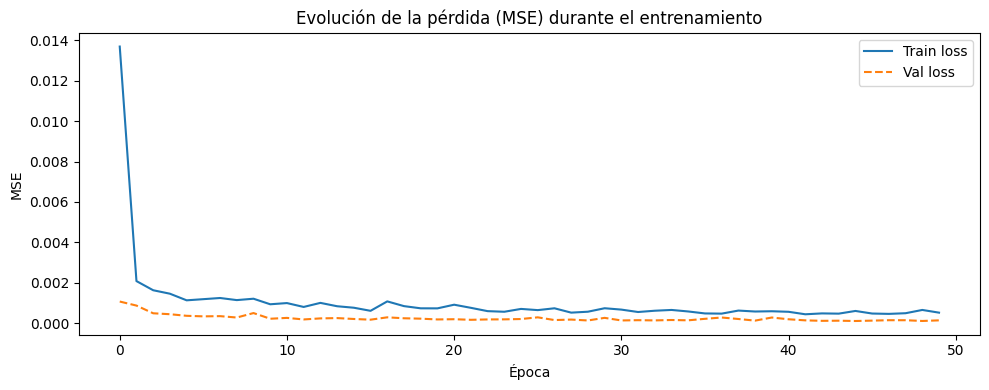

Modelo guardado en cnn_ae_weights.pth


In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

n_features = len(FEATURE_COLS)
model = ConvAutoencoder(n_features=n_features, seq_len=WINDOW_SIZE)
history = train_autoencoder(model, X_train, epochs=50, batch_size=64, lr=1e-3, val_split=0.1, device=device)
plot_training_history(history)
save_model(model, path='cnn_ae_weights.pth')

## 3) Inferencia con CNN-AE: MSE por ventana y semáforo básico
Explicación: calculamos el error de reconstrucción (MSE) para cada ventana. Con los errores del set de entrenamiento calibramos percentiles para definir Verde/Ámbar/Rojo.

Umbrales calibrados — Verde<0.000254  Ámbar<0.000446


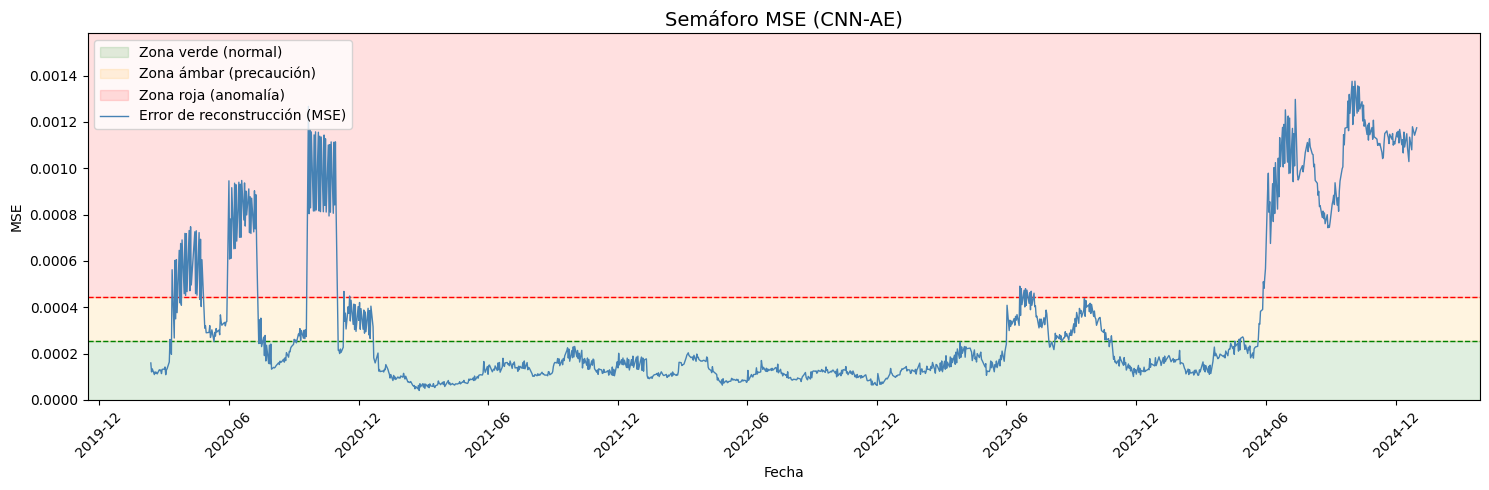

Distribución semáforo MSE (test): Counter({'verde': 833, 'rojo': 245, 'ámbar': 173})


In [16]:
# Errores en train (para calibrar)
train_errors = compute_reconstruction_errors(model, X_train, batch_size=256, device=device)
thresholds = calibrate_thresholds(train_errors, p_amber=90, p_red=97)

# Errores en test y semáforo simple por MSE
test_errors = compute_reconstruction_errors(model, X_test, batch_size=256, device=device)
plot_semaforo(test_dates, test_errors, thresholds, title='Semáforo MSE (CNN-AE)')

# Clasificación por MSE
labels = classify_signals(test_errors, thresholds)
from collections import Counter
print('Distribución semáforo MSE (test):', Counter(labels))

## 4) TCN: usar CNN-AE como extractor frozen y entrenar agente multitarea
Explicación: el encoder del `CNN-AE` genera vectores latentes `z` por ventana. Construimos secuencias de `z` (historia temporal) y las pasamos a una `TCN` que alimenta dos cabezas: clasificación (BUY/HOLD/SELL) y regresión (retorno esperado). El diseño sigue el notebook `tcn_agent_semaforoV3Bueno2.ipynb`.

In [49]:
# --- Definiciones TCN y agente (extraído y adaptado del notebook TCN existente) ---
import torch.nn as nn
import torch.nn.functional as F

class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation):
        super().__init__()
        self.pad = (kernel - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel, dilation=dilation, padding=0)
    def forward(self, x):
        return self.conv(F.pad(x, (self.pad, 0)))

class ResidualTCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1d(in_ch, out_ch, kernel, dilation),
            nn.BatchNorm1d(out_ch), nn.ReLU(), nn.Dropout(dropout),
            CausalConv1d(out_ch, out_ch, kernel, dilation),
            nn.BatchNorm1d(out_ch), nn.ReLU(), nn.Dropout(dropout),
        )
        self.downsample = (nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity())
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(self.net(x) + self.downsample(x))

class TCN(nn.Module):
    def __init__(self, input_dim, channels, kernel=3, dropout=0.1, output_dim=64):
        super().__init__()
        layers, in_ch = [], input_dim
        for i, out_ch in enumerate(channels):
            layers.append(ResidualTCNBlock(in_ch, out_ch, kernel, 2 ** i, dropout))
            in_ch = out_ch
        self.tcn = nn.Sequential(*layers)
        self.head = nn.Linear(channels[-1], output_dim)
    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.tcn(x)[:, :, -1]
        return self.head(x)

class SemaforoAgent(nn.Module):
    def __init__(self, z_dim, tcn_channels=None, tcn_kernel=3, dropout=0.3, context_dim=64):
        super().__init__()
        if tcn_channels is None:
            tcn_channels = [32, 16]
        self.tcn = TCN(z_dim, tcn_channels, tcn_kernel, dropout, context_dim)
        self.cls = nn.Sequential(nn.Linear(context_dim, 64), nn.ReLU(), nn.Linear(64, 3))
        self.reg = nn.Sequential(nn.Linear(context_dim, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, z):
        ctx = self.tcn(z)
        return self.cls(ctx), self.reg(ctx).squeeze(-1)

# Helpers: generar Z sequences usando el encoder congelado del CNN-AE
def build_zf_sequences(cnn_ae, X_windows, feat_windows, tcn_seq_len, device, batch_size=256):
    cnn_ae.eval()
    all_z = []
    for i in range(0, len(X_windows), batch_size):
        # Fix: Convert to tensor and permute to (Batch, Features, Seq_Len) for Conv1d
        batch = torch.tensor(X_windows[i:i+batch_size], dtype=torch.float32).to(device)
        batch = batch.permute(0, 2, 1)
        with torch.no_grad():
            z = cnn_ae.encoder(batch)
            z_flat = z.view(z.size(0), -1)
            all_z.append(z_flat.cpu().numpy())
    all_z = np.concatenate(all_z, axis=0).astype(np.float32)
    all_zf = np.concatenate([all_z, feat_windows.astype(np.float32)], axis=1)
    return np.array([all_zf[i:i+tcn_seq_len] for i in range(len(all_zf) - tcn_seq_len)])

def forward_returns(close, decision_offset, n_seqs, horizon):
    c = close.values.astype(np.float64)
    out = []
    for i in range(n_seqs):
        d = decision_offset + i
        if d + horizon >= len(c):
            break
        out.append(np.log(c[d + horizon] / c[d]))
    return np.asarray(out, dtype=np.float32)

def make_labels(fwd, thr=0.0):
    y = np.zeros(len(fwd), dtype=np.int64)
    y[fwd > thr] = 1
    y[fwd < -thr] = 2
    return y

def train_supervised(agent, z_train, fwd_train, r1_train, epochs=200, lr=3e-4, weight_decay=1e-3, thr=0.0, val_frac=0.2, batch_size=128, patience=40, min_epochs=40, label_smoothing=0.05, lambda_reg=10.0, device='cpu'):
    y_all = make_labels(fwd_train, thr)
    n_val = int(len(z_train) * val_frac)
    Xtr = torch.as_tensor(z_train[:-n_val], dtype=torch.float32, device=device)
    ytr = torch.as_tensor(y_all[:-n_val],   dtype=torch.long,    device=device)
    rtr = torch.as_tensor(r1_train[:-n_val], dtype=torch.float32, device=device)
    Xva = torch.as_tensor(z_train[-n_val:], dtype=torch.float32, device=device)
    yva = torch.as_tensor(y_all[-n_val:],   dtype=torch.long,    device=device)
    rva = torch.as_tensor(r1_train[-n_val:], dtype=torch.float32, device=device)
    fwd_va = fwd_train[-n_val:]

    params = list(agent.tcn.parameters()) + list(agent.cls.parameters()) + list(agent.reg.parameters())
    opt = torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)

    n = Xtr.shape[0]
    best_loss, best_state, best_ep, bad = float('inf'), None, 0, 0
    val_acc_hist = []
    for ep in range(epochs):
        agent.train()
        perm = torch.randperm(n, device=device)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            logits, rpred = agent(Xtr[idx])
            loss = (F.cross_entropy(logits, ytr[idx], label_smoothing=label_smoothing)
                    + lambda_reg * F.mse_loss(rpred, rtr[idx]))
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0); opt.step()

        agent.eval()
        with torch.no_grad():
            vlogits, vrpred = agent(Xva)
            vloss = (F.cross_entropy(vlogits, yva, label_smoothing=label_smoothing)
                     + lambda_reg * F.mse_loss(vrpred, rva)).item()
            vpred = vlogits.argmax(1).cpu().numpy()
        traded  = (vpred == 1) | (vpred == 2)
        correct = ((vpred == 1) & (fwd_va > 0)) | ((vpred == 2) & (fwd_va < 0))
        vacc = correct[traded].mean() if traded.sum() else float('nan')
        val_acc_hist.append(vacc)

        if vloss < best_loss - 1e-4:
            best_loss, best_ep, bad = vloss, ep, 0
            best_state = {k: v.detach().clone() for k, v in agent.state_dict().items()}
        else:
            bad += 1
        if ep + 1 >= min_epochs and bad >= patience:
            print(f'  Early stopping en epoch {ep+1}')
            break

    if best_state is not None:
        agent.load_state_dict(best_state)
    return val_acc_hist, best_ep

In [50]:
# --- Preparar features adicionales y construir secuencias para la TCN ---
# Corrección: Asegurar que el escalado NO use datos de test (Data Leakage)
df_full = processor.data.copy()
df_full['SMA_200'] = df_full['Close'].rolling(200).mean()
feat_full = pd.DataFrame(index=df_full.index)
feat_full['ret_5']     = np.log(df_full['Close'] / df_full['Close'].shift(5))
feat_full['ret_20']    = np.log(df_full['Close'] / df_full['Close'].shift(20))
feat_full['px_sma50']  = df_full['Close'] / df_full['SMA_50']  - 1.0
feat_full['px_sma200'] = df_full['Close'] / df_full['SMA_200'] - 1.0
feat_full['rsi']       = df_full['RSI_14'] / 100.0
feat_full['vol']       = df_full['Volatilidad']
feat_full = feat_full.fillna(0.0)

# Dividir ANTES de calcular estadísticas para escalar
feat_train = feat_full.loc[train_df.index]
feat_test  = feat_full.loc[test_df.index]

# Fit del escalador solo en train
fmean, fstd = feat_train.mean(), feat_train.std() + 1e-8
feat_train_sc = ((feat_train - fmean) / fstd).values.astype(np.float32)
feat_test_sc  = ((feat_test  - fmean) / fstd).values.astype(np.float32)

# Alinear con ventanas del CNN-AE
fw_train = feat_train_sc[WINDOW_SIZE - 1: WINDOW_SIZE - 1 + len(X_train)]
fw_test  = feat_test_sc[WINDOW_SIZE - 1: WINDOW_SIZE - 1 + len(X_test)]

cnn_ae = model
TCN_SEQ_LEN = 10
TCN_CHANNELS = [32, 16]
DEVICE = device

z_train = build_zf_sequences(cnn_ae, X_train, fw_train, TCN_SEQ_LEN, DEVICE)
z_test  = build_zf_sequences(cnn_ae, X_test,  fw_test,  TCN_SEQ_LEN, DEVICE)

# Offset para decisiones (importante: debe ser consistente)
DEC_OFFSET = WINDOW_SIZE + TCN_SEQ_LEN - 2

close_train = df_full['Close'].loc[train_df.index]
close_test  = df_full['Close'].loc[test_df.index]

fwd_train = forward_returns(close_train, DEC_OFFSET, len(z_train), horizon=8)
r1_train = forward_returns(close_train, DEC_OFFSET, len(z_train), horizon=1)

minlen = min(len(z_train), len(fwd_train), len(r1_train))
z_train, fwd_train, r1_train = z_train[:minlen], fwd_train[:minlen], r1_train[:minlen]

Z_DIM = z_train.shape[2]
agent = SemaforoAgent(z_dim=Z_DIM, tcn_channels=TCN_CHANNELS, tcn_kernel=3, dropout=0.3, context_dim=64).to(DEVICE)
history, best_ep = train_supervised(agent, z_train, fwd_train, r1_train, epochs=100, lr=3e-4, device=DEVICE)

  Early stopping en epoch 56


label
HOLD    867
BUY     187
SELL    187
Name: count, dtype: int64


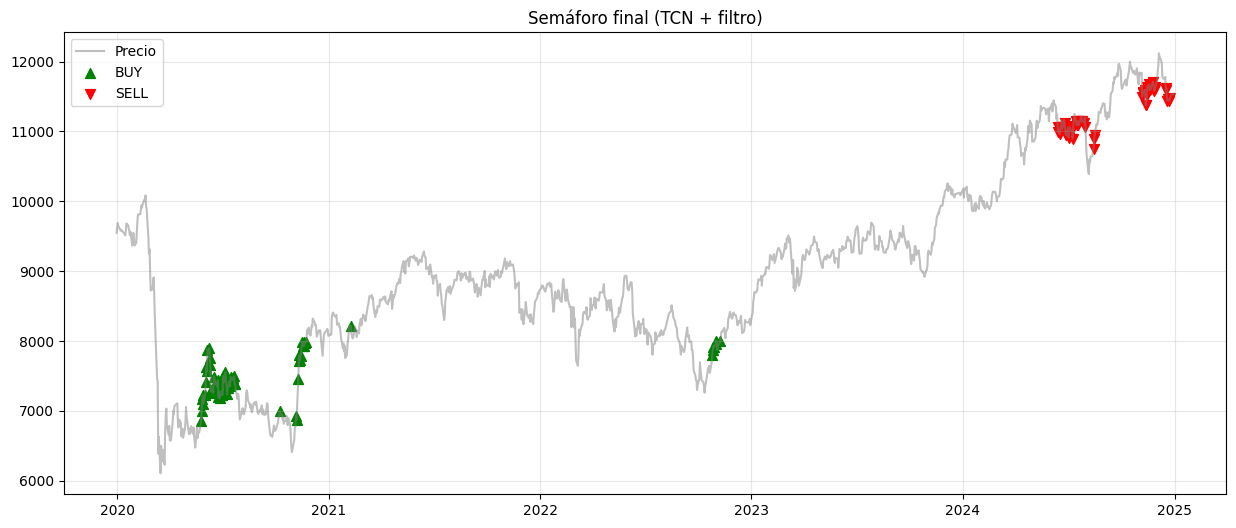

In [51]:
# --- Inferencia y semáforo final ---
def run_inference_df(agent, z_sequences, dates, device, coverage=0.30):
    agent.eval()
    P, R = [], []
    for i in range(len(z_sequences)):
        x = torch.tensor(z_sequences[i], dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            logits, rpred = agent(x)
            P.append(F.softmax(logits, dim=-1).squeeze().cpu().numpy())
            R.append(float(rpred.cpu()))
    P, R = np.array(P), np.array(R)
    score = P[:,1] - P[:,2]
    lo = np.quantile(score, coverage/2)
    hi = np.quantile(score, 1 - coverage/2)
    actions = np.where(score >= hi, 1, np.where(score <= lo, 2, 0))
    return pd.DataFrame({
        'date': dates[:len(actions)], 'action': actions,
        'label': [ {0:'HOLD',1:'BUY',2:'SELL'}[a] for a in actions],
        'p_hold': P[:,0], 'p_buy': P[:,1], 'p_sell': P[:,2], 'r_pred': R,
    }).set_index('date')

def plot_trading_signals(signals_df, close_series, title='Semáforo TCN'):
    plt.figure(figsize=(15, 6))
    plt.plot(close_series.index, close_series.values, color='gray', alpha=0.5, label='Precio')

    # Alinear señales con el precio
    df_plot = signals_df.reindex(close_series.index)

    buys = close_series[df_plot['action'] == 1]
    sells = close_series[df_plot['action'] == 2]

    plt.scatter(buys.index, buys.values, marker='^', color='green', label='BUY', alpha=1, s=50)
    plt.scatter(sells.index, sells.values, marker='v', color='red', label='SELL', alpha=1, s=50)

    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

signals = run_inference_df(agent, z_test, test_dec_dates, DEVICE, coverage=0.30)
print(signals['label'].value_counts())

# Aplicar filtro de tendencia simple (opcional)
def apply_trend_gate_simple(signals, df, fast=50, dd_look=20, dd_thr=-0.08):
    close = df['Close']
    sma = close.rolling(fast).mean()
    ret_r = np.log(close / close.shift(dd_look))
    bullish = ((close > sma) & (ret_r > dd_thr)).reindex(signals.index).fillna(False).values
    act = signals['action'].values.copy()
    act[bullish & (act == 2)] = 0
    act[~bullish & (act == 1)] = 0
    out = signals.copy()
    out['action'] = act
    out['label'] = [ {0:'HOLD',1:'BUY',2:'SELL'}[a] for a in act ]
    return out

signals_f = apply_trend_gate_simple(signals, df_full)
# Usamos la nueva función de plotting para evitar el error de argumentos
plot_trading_signals(signals_f, df_full['Close'].loc[test_df.index], title='Semáforo final (TCN + filtro)')

### Comparativa Multiactivo: IBEX 35 vs Oro vs S&P 500
En esta sección automatizamos el pipeline para procesar diferentes activos y comparar cómo se comportan las anomalías (MSE) y las señales del agente en distintos mercados.

In [52]:
def run_full_pipeline(ticker_symbol, name):
    print(f'\n=== Procesando {name} ({ticker_symbol}) ===')

    # 1. Carga y Procesado
    proc = DataProcessor(ticker=ticker_symbol, start_date=START_DATE, end_date=END_DATE)
    proc.download_data()
    proc.add_features()
    d_df = proc.data

    f_df = d_df[FEATURE_COLS].copy()
    tr_df, ts_df = f_df[:STABILITY_END], f_df[STABILITY_END:]

    scl = MinMaxScaler().fit(tr_df)
    tr_sc = scl.transform(tr_df)
    ts_sc = scl.transform(ts_df)

    xtr = make_windows(tr_sc)
    xts = make_windows(ts_sc)

    # 2. CNN-AE (Entrenamiento rápido para este activo)
    ae = ConvAutoencoder(n_features=len(FEATURE_COLS), seq_len=WINDOW_SIZE).to(DEVICE)
    train_autoencoder(ae, xtr, epochs=20, batch_size=64, device=DEVICE)

    # 3. Features para TCN
    feat_f = pd.DataFrame(index=d_df.index)
    feat_f['ret_5'] = np.log(d_df['Close'] / d_df['Close'].shift(5))
    feat_f['ret_20'] = np.log(d_df['Close'] / d_df['Close'].shift(20))
    feat_f['px_sma50'] = d_df['Close'] / d_df['SMA_50'] - 1.0
    feat_f['px_sma200'] = d_df['Close'] / d_df['SMA_200'] - 1.0
    feat_f['rsi'] = d_df['RSI_14'] / 100.0
    feat_f['vol'] = d_df['Volatilidad']
    feat_f = feat_f.fillna(0.0)

    f_tr = feat_f.loc[tr_df.index]
    f_ts = feat_f.loc[ts_df.index]
    fm, fs = f_tr.mean(), f_tr.std() + 1e-8
    f_tr_sc = ((f_tr - fm) / fs).values.astype(np.float32)
    f_ts_sc = ((f_ts - fm) / fs).values.astype(np.float32)

    fw_tr = f_tr_sc[WINDOW_SIZE - 1 : WINDOW_SIZE - 1 + len(xtr)]
    fw_ts = f_ts_sc[WINDOW_SIZE - 1 : WINDOW_SIZE - 1 + len(xts)]

    # 4. Construir Secuencias Z (Necesitamos train para entrenar el TCN)
    z_tr = build_zf_sequences(ae, xtr, fw_tr, TCN_SEQ_LEN, DEVICE)
    z_ts = build_zf_sequences(ae, xts, fw_ts, TCN_SEQ_LEN, DEVICE)

    # Targets para entrenamiento
    c_tr = d_df['Close'].loc[tr_df.index]
    fwd_tr = forward_returns(c_tr, DEC_OFFSET, len(z_tr), horizon=8)
    r1_tr = forward_returns(c_tr, DEC_OFFSET, len(z_tr), horizon=1)

    ml = min(len(z_tr), len(fwd_tr), len(r1_tr))
    z_tr, fwd_tr, r1_tr = z_tr[:ml], fwd_tr[:ml], r1_tr[:ml]

    # 5. Inicializar y ENTRENAR el Agente TCN
    current_z_dim = z_ts.shape[2]
    local_agent = SemaforoAgent(z_dim=current_z_dim, tcn_channels=TCN_CHANNELS, tcn_kernel=3, dropout=0.3, context_dim=64).to(DEVICE)

    print(f'Entrenando TCN para {name}...')
    train_supervised(local_agent, z_tr, fwd_tr, r1_tr, epochs=50, lr=3e-4, device=DEVICE)

    # 6. Inferencia
    t_dates = ts_df.index[DEC_OFFSET : DEC_OFFSET + len(z_ts)]
    res_signals = run_inference_df(local_agent, z_ts, t_dates, DEVICE)

    return res_signals, d_df['Close']

/content/TFE/load_data.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start=self.start_date, end=self.end_date)
[*********************100%***********************]  1 of 1 completed


=== Procesando IBEX 35 (^IBEX) ===
Descargando datos para ^IBEX...
Características añadidas. Columnas actuales: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']
Entrenando en: cpu


  Epoch  10/20  |  train=0.000918  val=0.000270
  Epoch  20/20  |  train=0.000593  val=0.000153
Entrenando TCN para IBEX 35...


/content/TFE/load_data.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start=self.start_date, end=self.end_date)
[*********************100%***********************]  1 of 1 completed


=== Procesando S&P 500 (^GSPC) ===
Descargando datos para ^GSPC...
Características añadidas. Columnas actuales: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']
Entrenando en: cpu


  Epoch  10/20  |  train=0.000619  val=0.001731
  Epoch  20/20  |  train=0.000416  val=0.001038
Entrenando TCN para S&P 500...
  Early stopping en epoch 44


/content/TFE/load_data.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start=self.start_date, end=self.end_date)
[*********************100%***********************]  1 of 1 completed


=== Procesando Oro (GC=F) ===
Descargando datos para GC=F...
Características añadidas. Columnas actuales: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']
Entrenando en: cpu


  Epoch  10/20  |  train=0.000839  val=0.000678
  Epoch  20/20  |  train=0.000804  val=0.002152
Entrenando TCN para Oro...


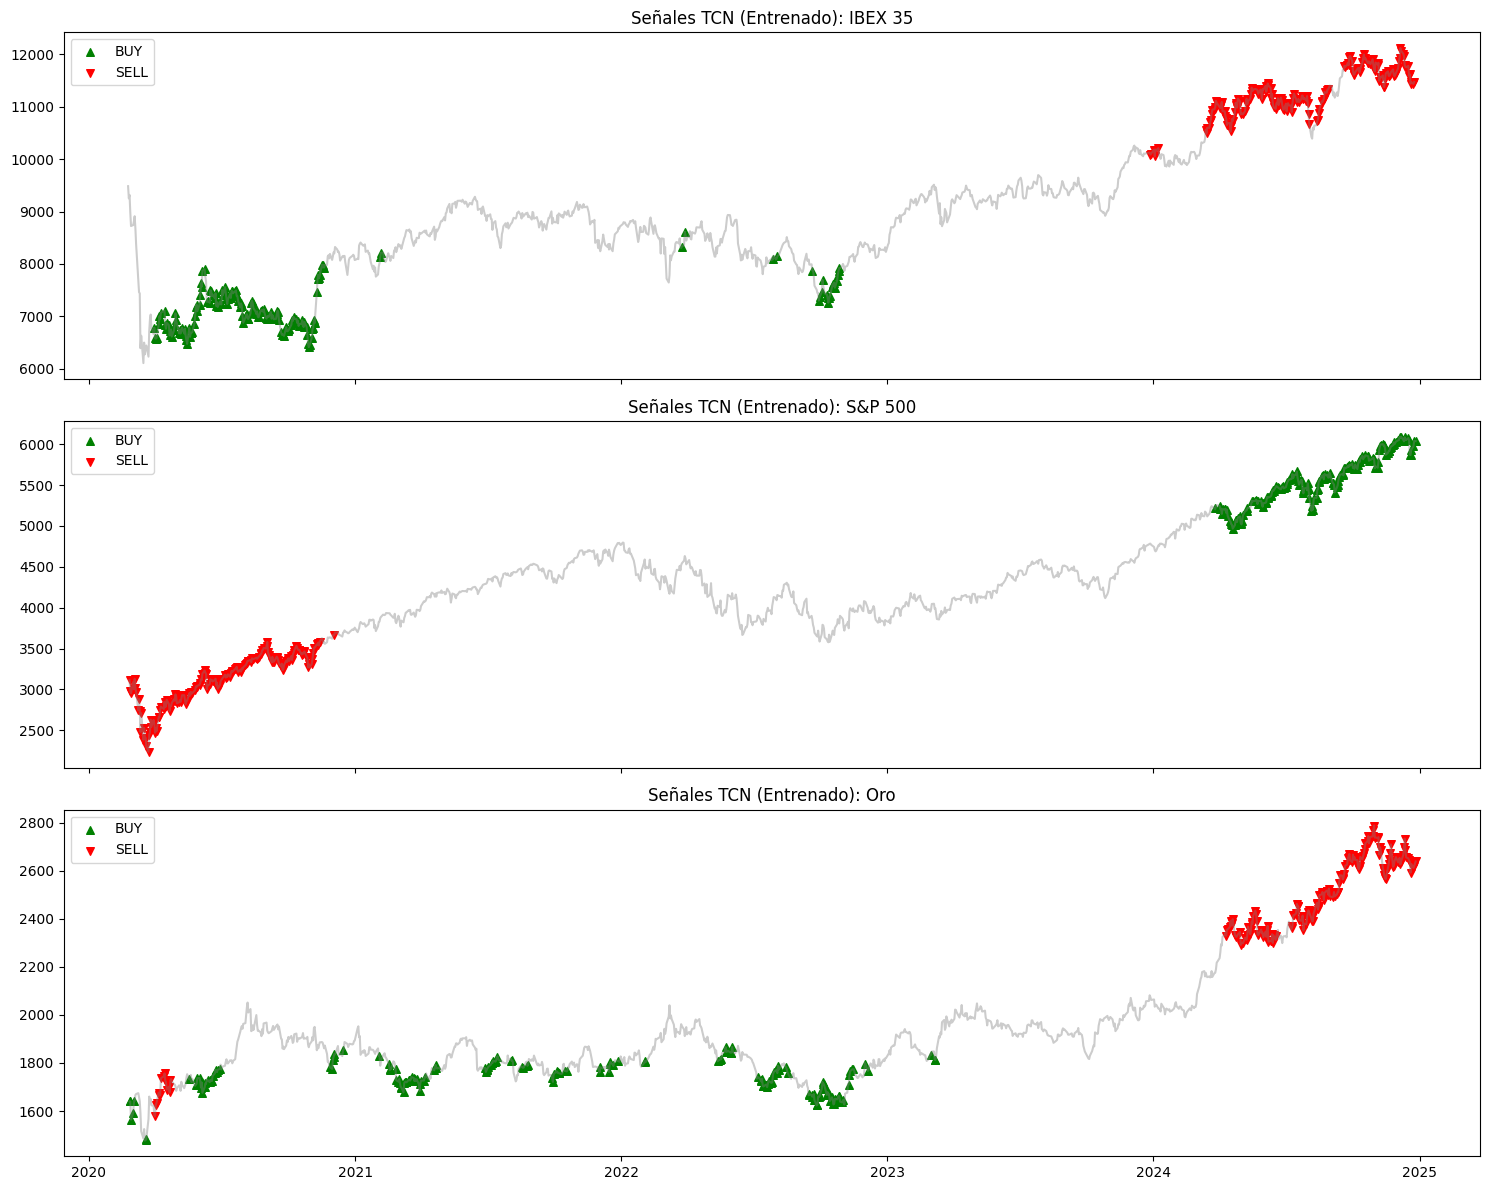

In [53]:
# Activos a comparar
assets = {
    '^IBEX': 'IBEX 35',
    '^GSPC': 'S&P 500',
    'GC=F': 'Oro'
}

# Diccionario para guardar resultados reales
results = {}

for ticker, name in assets.items():
    try:
        # Ejecutamos el pipeline completo (ahora incluye entrenamiento del TCN)
        res_sig, close_p = run_full_pipeline(ticker, name)
        results[ticker] = (res_sig, close_p)
    except Exception as e:
        import traceback
        print(f'Error procesando {name}: {e}')
        traceback.print_exc()

# Visualización de las señales generadas tras el entrenamiento
if results:
    fig, axes = plt.subplots(len(results), 1, figsize=(15, 4 * len(results)), sharex=True)
    if len(results) == 1: axes = [axes]

    for i, (ticker, (sig, price)) in enumerate(results.items()):
        ax = axes[i]
        # Alinear precio con el periodo de test de las señales
        p_sub = price.loc[sig.index]
        ax.plot(p_sub.index, p_sub.values, color='gray', alpha=0.4)

        buys = p_sub[sig['action'] == 1]
        sells = p_sub[sig['action'] == 2]
        ax.scatter(buys.index, buys.values, marker='^', color='green', s=30, label='BUY')
        ax.scatter(sells.index, sells.values, marker='v', color='red', s=30, label='SELL')
        ax.set_title(f'Señales TCN (Entrenado): {assets[ticker]}')
        ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print('No se generaron resultados.')

In [54]:
import numpy as np
import pandas as pd

def calculate_performance_metrics(returns):
    if len(returns) == 0: return 0, 0, 0
    cum_ret = (1 + returns).prod() - 1
    ann_ret = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 1e-6 else 0

    cum_prod = (1 + returns).cumprod()
    peak = cum_prod.cummax()
    dd = (cum_prod - peak) / peak
    max_dd = dd.min()
    return cum_ret, sharpe, max_dd

def run_comprehensive_backtest(ticker, sig_df, price_series):
    rets = price_series.pct_change().reindex(sig_df.index).fillna(0)
    bh_metrics = calculate_performance_metrics(rets)

    # Benchmark: Medias Móviles (SMA 50/200)
    # Aplicamos shift(1) para no usar el precio de cierre de hoy para decidir hoy mismo
    sma_fast = price_series.rolling(50).mean().reindex(sig_df.index)
    sma_slow = price_series.rolling(200).mean().reindex(sig_df.index)
    sma_signal = (sma_fast > sma_slow).astype(int).shift(1).fillna(0)
    sma_rets = sma_signal * rets
    sma_metrics = calculate_performance_metrics(sma_rets)

    # Estrategia TCN
    # La señal de 'action' generada al cierre de t se ejecuta en t+1
    tcn_signal = (sig_df['action'] == 1).astype(int).shift(1).fillna(0)
    tcn_rets = tcn_signal * rets
    tcn_metrics = calculate_performance_metrics(tcn_rets)

    return {
        'Asset': ticker,
        'B&H Ret': bh_metrics[0], 'B&H Sharpe': bh_metrics[1], 'B&H MaxDD': bh_metrics[2],
        'SMA Ret': sma_metrics[0], 'SMA Sharpe': sma_metrics[1], 'SMA MaxDD': sma_metrics[2],
        'TCN Ret': tcn_metrics[0], 'TCN Sharpe': tcn_metrics[1], 'TCN MaxDD': tcn_metrics[2]
    }

final_comparison = []
for tck, (sig, prc) in results.items():
    final_comparison.append(run_comprehensive_backtest(tck, sig, prc))

summary_df = pd.DataFrame(final_comparison).set_index('Asset')

print("\n--- TABLA DE MÉTRICAS FINALES (RESUMEN EJECUTIVO) ---")
display(summary_df.style.format({
    'B&H Ret': '{:.2%}', 'B&H MaxDD': '{:.2%}', 'B&H Sharpe': '{:.2f}',
    'SMA Ret': '{:.2%}', 'SMA MaxDD': '{:.2%}', 'SMA Sharpe': '{:.2f}',
    'TCN Ret': '{:.2%}', 'TCN MaxDD': '{:.2%}', 'TCN Sharpe': '{:.2f}'
}))


--- TABLA DE MÉTRICAS FINALES (RESUMEN EJECUTIVO) ---


,B&H Ret,B&H Sharpe,B&H MaxDD,SMA Ret,SMA Sharpe,SMA MaxDD,TCN Ret,TCN Sharpe,TCN MaxDD
Asset,,,,,,,,,
^IBEX,16.06%,0.25,-35.60%,-9.24%,-0.06,-35.60%,41.14%,0.73,-15.15%
^GSPC,93.00%,0.74,-28.52%,61.19%,0.66,-28.52%,12.69%,0.51,-8.49%
GC=F,60.23%,0.68,-20.87%,23.06%,0.37,-26.27%,29.25%,0.87,-6.58%


### Interpretación de resultados

- **Sharpe Ratio > 1**: Se considera una gestión de riesgo excelente.
- **Max Drawdown**: Queremos que sea lo más pequeño posible (menos negativo). Si el modelo TCN tiene un MaxDD significativamente menor que B&H, está cumpliendo su función de 'semáforo' protegiendo el capital en caídas.
- **Comparación con SMA**: Las medias móviles son el 'benchmark' a batir para cualquier modelo de tendencia. Si el TCN no supera a las SMA, puede que necesitemos ajustar el umbral de confianza (`coverage`) o las features de entrada.

## Conclusiones y siguientes pasos
- Este notebook reproduce el flujo del repositorio: preprocesado → CNN-AE → MSE-semaforo → TCN-agent → semáforo final.
- Recomendaciones: probar varios `FEATURE_COLS`, ajustar `WINDOW_SIZE`, experimentar con la dimensión latente y `TCN` depth/width, y realizar backtests económicos reales (incluyendo costes de transacción).

¿Quieres que ejecute el notebook localmente aquí (ejecutar celdas y guardar salida), o que adapte alguna celda para correr en Google Colab específicamente?